In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('~/repositories/go_figure/ClassicScience.mplstyle')

# plt.rcParams.update({
#     "font.family": "serif",
#     "text.usetex": True})

plt.rcParams.update({
    # "font.family"       : "serif",
    # "text.usetex"       : True,

    # No minor ticks => half as many tick marks immediately
    "xtick.minor.visible": False,
    "ytick.minor.visible": False,

    # … optional cosmetics
    "xtick.major.size"  : 4,     # length  of the remaining ticks
    "ytick.major.size"  : 4,
    "xtick.major.width" : 0.9,   # thickness of the ticks
    "ytick.major.width" : 0.9,
})

%load_ext autoreload
%autoreload 2

In [2]:
import sys,os
sys.path.insert(0, os.path.abspath("/Users/lucas/repositories/degeneracy_distillery/results/"))

os.chdir("/Users/lucas/repositories/degeneracy_distillery/results/")

In [3]:
rosen_results = np.load("./ex_rosen_31_03/fishnets_outputs_rosenbrock.npz")
rosen_results

NpzFile './ex_rosen_31_03/fishnets_outputs_rosenbrock.npz' with keys: theta, Fs, mle, ensemble_weights, x

In [46]:
rosen_results = np.load("./ex_rosen/fishnets_outputs_rosen2.npz")
rosen_results

NpzFile './ex_rosen/fishnets_outputs_rosen2.npz' with keys: theta, Fs, mle, ensemble_weights, x

In [4]:
import jax
import jax.numpy as jnp
import jax.random as jr
import flax.linen as nn
import optax

import numpy as np
import math
from typing import Sequence
from tqdm import tqdm
import yaml,os,sys
import argparse

from sklearn.preprocessing import MinMaxScaler
from scipy.stats import linregress

#import tensorflow_probability.substrates.jax as tfp

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

# --- Helper functions for prediction ---
def predicted_fishers(model, w, data):
    def _getf(d):
        return model.apply(w, d)[1]
    return jax.vmap(_getf)(data)

def predicted_mle(model, w, data):
    def _getmle(d):
        return model.apply(w, d)[0]
    return jax.vmap(_getmle)(data)



# Function to load yaml configuration file
def load_config(config_name, config_path="./"):
    with open(os.path.join(config_path, config_name)) as file:
        config = yaml.safe_load(file)

    return config



def mu_x_from_y(y):
  x0 = y[0]
  x1 = y[1] - x0**2

  return jnp.array([x0, x1])

def mu_y_from_x(x):
  return jnp.array([x[0], x[1] + x[0]**2])


#@jax.jit
def Fisher(θ, nd):
    #cov = jnp.eye(dim)
    cov = (Sigma)
    invC = jnp.linalg.inv(cov)

    mu_x = θ

    #dμ_dθ = jax.jacrev(mu_x_from_y)(θ)
    # do the simple case first
    return nd * jnp.array([[(1/cov[0,0] + 4*mu_x[0]**2 / cov[1,1]), -2*mu_x[0]/cov[1,1]], 
                        [(-2*mu_x[0] / cov[1,1]), 1/cov[1,1]]])


# -------------- CREATE PLOT --------------

def make_fisher_plot(network_fishers, filename):
    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(8,4), sharex="col", sharey=True)
    (ax1, ax2) = axs

    dets1 =  jax.vmap(jnp.linalg.det)(jnp.array(fishers)).reshape(xs.shape)

    dets1 = 0.5*np.log(dets1)
    levels = 10 #np.linspace(dets1.min(), dets1.max(), 10) #[1.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]

    ax1.contourf(xs, ys, dets1, cmap='viridis', levels=levels)
    dets2 = jax.vmap(jnp.linalg.det)(network_fishers).reshape(xs.shape)
    cs2 = ax2.contourf(xs, ys, 0.5*np.log(dets2), cmap='viridis', levels=levels)
    plt.colorbar(cs2)

    ax1.set_title(r'$ \frac{1}{2} \ln \det F_{\rm true}(\theta)$')
    ax1.set_xlabel(r'$\mu_1$')
    ax2.set_ylabel(r'$\mu_2$')
    ax2.set_title(r'$ \frac{1}{2} \ln \det \langle F_{\rm NN}(\theta) \rangle $')
    plt.tight_layout()
    if not filename.endswith(('.png', '.pdf', '.jpg', '.svg')):
        filename = filename + '.png'
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    print(f"Saved grid plot to: {filename}")

    plt.close()




def make_fisher_plot_twopanel(network_fishers, filename):

    fig = plt.figure(figsize=(12, 7))

    # exact fishers
    dets1 =  jax.vmap(jnp.linalg.det)(jnp.array(network_fishers)).reshape(xs.shape)
    dets1 = 0.5*np.log(dets1)
    levels = 10

    ax1 = fig.add_subplot(121)
    im1 = ax1.contourf(xs, ys, dets1, cmap='viridis', levels=levels)

    divider = make_axes_locatable(ax1)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im1, cax=cax, orientation='vertical')

    # network fishers
    ax2 = fig.add_subplot(122)
    dets2 = jax.vmap(jnp.linalg.det)(network_fishers).reshape(xs.shape)
    im2 = ax2.contourf(xs, ys, 0.5*np.log(dets2), cmap='viridis', levels=levels)

    divider = make_axes_locatable(ax2)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im2, cax=cax, orientation='vertical')

    # labels
    ax1.set_title(r'$ \frac{1}{2} \ln \det F_{\rm true}(\theta)$')
    ax1.set_xlabel(r'$\mu_1$')
    ax2.set_ylabel(r'$\mu_2$')
    ax2.set_title(r'$ \frac{1}{2} \ln \det \langle F_{\rm NN}(\theta) \rangle $')
    plt.tight_layout()
    if not filename.endswith(('.png', '.pdf', '.jpg', '.svg')):
        filename = filename + '.png'
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    print(f"Saved grid plot to: {filename}")

    plt.close()




def weighted_std(values, weights, axis=0):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    average = jnp.average(values, weights=weights, axis=axis)
    # Fast and numerically precise:
    variance = jnp.average((values-average)**2, weights=weights, axis=axis)
    return jnp.sqrt(variance)


def normalize_to_correlation(F):
    """
    Convert Fisher matrix to correlation-like form.
    Normalizes by diagonal elements so diagonal = 1.
    Off-diagonals become relative ratios.
    """
    diag_sqrt = jnp.sqrt(jnp.diagonal(F, axis1=-2, axis2=-1))
    diag_sqrt_inv = 1.0 / diag_sqrt
    return F * diag_sqrt_inv[..., :, None] * diag_sqrt_inv[..., None, :]


def normalize_by_trace(F):
    """
    Normalize Fisher matrix by its trace.
    Preserves all relative ratios while removing overall scale.
    """
    return F / jnp.trace(F, axis1=-2, axis2=-1)[..., None, None]


def predictive_histogram(F_avg, F_std, true_Fishers, 
                        title="Fisher Matrix",
                        filename="fisher_components_hist",
                        matrix_label="F",
                        abs_offdiag=False):
    """
    Create a 3-panel histogram plot comparing predicted vs true Fisher matrix components.
    
    Parameters:
        F_avg: Predicted mean Fisher matrices [n_samples, n_params, n_params]
        F_std: Predicted std Fisher matrices [n_samples, n_params, n_params]
        true_Fishers: True Fisher matrices [n_samples, n_params, n_params]
        title: Title for the plot
        filename: Filename to save the plot
        matrix_label: Label for matrix components (e.g., 'F' or 'L')
        abs_offdiag: Whether to take absolute value of off-diagonal elements
    """
    
    plt.figure(figsize=(7, 3))
    
    # Component [0,0]
    plt.subplot(131)
    mus_pred = F_avg[:, 0, 0]
    mus_sig = F_std[:, 0, 0]
    mus_true = true_Fishers[..., 0, 0]
    trace_to_plot = (mus_pred - mus_true) / mus_sig
    
    plt.hist(np.random.normal(0.0, scale=1.0, size=(10000,)),
             bins=np.linspace(-10, 10, num=50), density=True, label="normal")
    plt.hist(trace_to_plot, alpha=0.45, density=True,
             bins=np.linspace(-10, 10, num=50), label="data")
    plt.xlabel(rf"$(\hat{{{matrix_label}}}_{{{0}{0}}} - {matrix_label}_{{{0}{0}}}) / \delta\hat{{{matrix_label}}}_{{{0}{0}}}$")
    plt.legend(framealpha=0.0)
    
    # Component [0,1]
    plt.subplot(132)
    mus_pred = jnp.abs(F_avg[:, 0, 1]) if abs_offdiag else F_avg[:, 0, 1]
    mus_sig = F_std[:, 0, 1]
    mus_true = jnp.abs(true_Fishers[..., 0, 1]) if abs_offdiag else true_Fishers[..., 0, 1]
    trace_to_plot = (mus_pred - mus_true) / mus_sig
    
    plt.hist(np.random.normal(0.0, scale=1.0, size=(10000,)),
             bins=np.linspace(-10, 10, num=50), density=True, label="normal")
    plt.hist(trace_to_plot, alpha=0.45, density=True,
             bins=np.linspace(-10, 10, num=50), label="data")
    plt.xlabel(rf"$(\hat{{{matrix_label}}}_{{{0}{1}}} - {matrix_label}_{{{0}{1}}}) / \delta\hat{{{matrix_label}}}_{{{0}{1}}}$")
    plt.legend(framealpha=0.0)
    
    # Component [1,1]
    plt.subplot(133)
    mus_pred = F_avg[:, 1, 1]
    mus_sig = F_std[:, 1, 1]
    mus_true = true_Fishers[..., 1, 1]
    trace_to_plot = (mus_pred - mus_true) / mus_sig
    
    plt.hist(np.random.normal(0.0, scale=1.0, size=(10000,)),
             bins=np.linspace(-10, 10, num=50), density=True, label="normal")
    plt.hist(trace_to_plot, alpha=0.45, density=True,
             bins=np.linspace(-10, 10, num=50), label="data")
    plt.xlabel(rf"$(\hat{{{matrix_label}}}_{{{1}{1}}} - {matrix_label}_{{{1}{1}}}) / \delta\hat{{{matrix_label}}}_{{{1}{1}}}$")
    plt.legend(framealpha=0.0)
    
    plt.suptitle(title)
    plt.tight_layout()
    if not filename.endswith(('.png', '.pdf', '.jpg', '.svg')):
        filename = filename + '.png'
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    print(f"Saved histogram plot to: {filename}")
    plt.show()


def predictive_scatter(F_avg, true_Fishers,
                      title="Fisher Matrix predictive",
                      filename="fisher_components",
                      matrix_label="F",
                      abs_offdiag=False,
                      do_regression=False):
    """
    Create a 3-panel scatter plot comparing predicted vs true Fisher matrix components.
    
    Parameters:
        F_avg: Predicted mean Fisher matrices [n_samples, n_params, n_params]
        true_Fishers: True Fisher matrices [n_samples, n_params, n_params]
        title: Title for the plot
        filename: Filename to save the plot
        matrix_label: Label for matrix components (e.g., 'F' or 'L')
        abs_offdiag: Whether to take absolute value of off-diagonal elements
        do_regression: Whether to compute and print linear regression results
    """
    
    plt.figure(figsize=(7, 3))
    
    # Component [0,0]
    plt.subplot(131)
    mus_pred = F_avg[:, 0, 0]
    mus_true = true_Fishers[..., 0, 0]
    
    plt.scatter(mus_true, mus_pred, alpha=0.45, label="data", s=2)
    plt.plot(mus_true, mus_true, ls=':', c='k')
    plt.xlabel(rf"${matrix_label}_{{{0}{0}}}$")
    plt.ylabel(rf"$\hat{{{matrix_label}}}_{{{0}{0}}}$")
    plt.legend(framealpha=0.0)
    
    # if do_regression:
        # result = linregress(mus_true, mus_pred)
        # print(f"{matrix_label}_00 regression: slope={result.slope:.4f}, intercept={result.intercept:.4f}")
    
    # Component [0,1]
    plt.subplot(132)
    mus_pred = jnp.abs(F_avg[:, 0, 1]) if abs_offdiag else F_avg[:, 0, 1]
    mus_true = jnp.abs(true_Fishers[..., 0, 1]) if abs_offdiag else true_Fishers[..., 0, 1]
    
    plt.scatter(mus_true, mus_pred, alpha=0.45, label="data", s=2)
    plt.plot(mus_true, mus_true, ls=':', c='k')
    plt.xlabel(rf"${matrix_label}_{{{0}{1}}}$")
    plt.ylabel(rf"$\hat{{{matrix_label}}}_{{{0}{1}}}$")
    plt.legend(framealpha=0.0)
    
    # if do_regression:
        # result = linregress(mus_true, mus_pred)
        # print(f"{matrix_label}_01 regression: slope={result.slope:.4f}, intercept={result.intercept:.4f}")
    
    # Component [1,1]
    plt.subplot(133)
    mus_pred = F_avg[:, 1, 1]
    mus_true = true_Fishers[..., 1, 1]
    
    plt.scatter(mus_true, mus_pred, alpha=0.45, label="data", s=2)
    plt.plot(mus_true, mus_true, ls=':', c='k')
    plt.xlabel(rf"${matrix_label}_{{{1}{1}}}$")
    plt.ylabel(rf"$\hat{{{matrix_label}}}_{{{1}{1}}}$")
    plt.legend(framealpha=0.0)
    
    # if do_regression:
        # result = linregress(mus_true, mus_pred)
        # print(f"{matrix_label}_11 regression: slope={result.slope:.4f}, intercept={result.intercept:.4f}")
    
    plt.suptitle(title)
    plt.tight_layout()
    if not filename.endswith(('.png', '.pdf', '.jpg', '.svg')):
        filename = filename + '.png'
    plt.savefig(filename, dpi=400, bbox_inches='tight')
    print(f"Saved scatter plot to: {filename}")
    plt.show()

    

In [5]:
def normalize_to_correlation(F):
    """
    Convert Fisher matrix to correlation-like form.
    Normalizes by diagonal elements so diagonal = 1.
    Off-diagonals become relative ratios.
    """
    diag_sqrt = jnp.sqrt(jnp.diagonal(F, axis1=-2, axis2=-1))
    diag_sqrt_inv = 1.0 / diag_sqrt
    return F * diag_sqrt_inv[..., :, None] * diag_sqrt_inv[..., None, :]


def normalize_by_trace(F):
    """
    Normalize Fisher matrix by its trace.
    Preserves all relative ratios while removing overall scale.
    """
    return F / jnp.trace(F, axis1=-2, axis2=-1)[..., None, None]

In [8]:
rosen_results

NpzFile './ex_rosen/fishnets_outputs_rosenbrock.npz' with keys: theta, Fs, mle, ensemble_weights, x

Sigma = [[1. 0.]
 [0. 4.]]
num sims below thresh 10000


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved MLE predictions plot to: mle_predictions.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


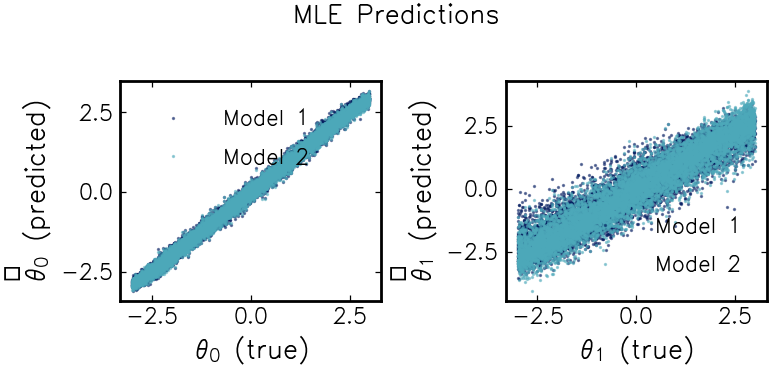

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/pyparsing/core.py:287: UserWarning: Glyph 164 (\N{CURRENCY SIGN}) missing from font(s) HersheySimplex.
  return func(*args[limit:])
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy s

Saved histogram plot to: fisher_components_hist.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


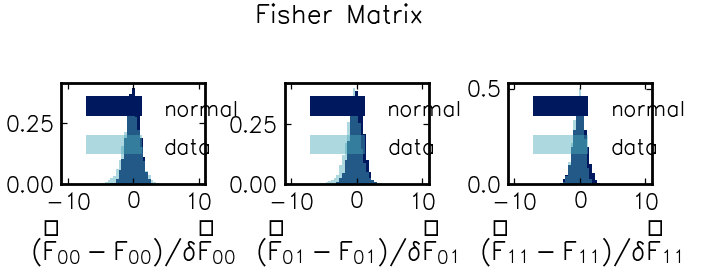

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/pyparsing/core.py:287: UserWarning: Glyph 164 (\N{CURRENCY SIGN}) missing from font(s) HersheySimplex.
  return func(*args[limit:])
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy s

Saved scatter plot to: fisher_components.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


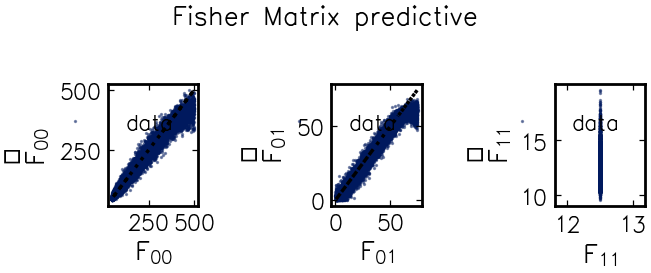

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/pyparsing/core.py:287: UserWarning: Glyph 164 (\N{CURRENCY SIGN}) missing from font(s) HersheySimplex.
  return func(*args[limit:])
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy s

Saved histogram plot to: cholesky_factors_hist.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


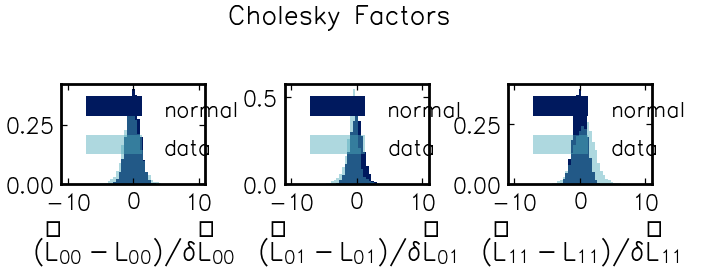

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved scatter plot to: cholesky_components.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


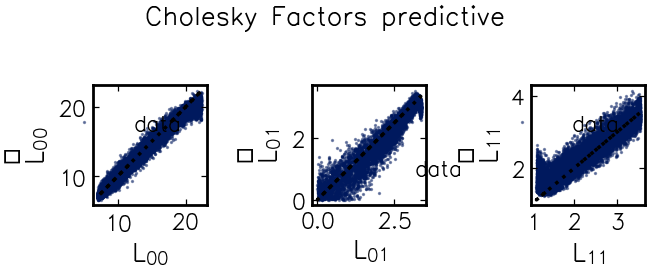

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/pyparsing/core.py:287: UserWarning: Glyph 164 (\N{CURRENCY SIGN}) missing from font(s) HersheySimplex.
  return func(*args[limit:])
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy s

Saved histogram plot to: shape_components_hist.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


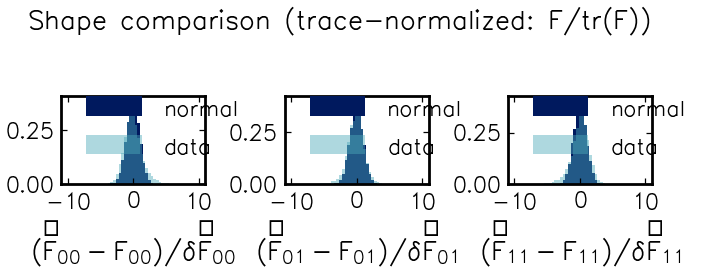

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved scatter plot to: shapes.png


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


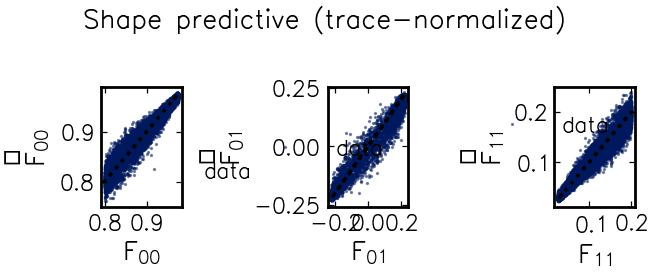

In [6]:




# ============================================================================
# CONFIGURATION
# ============================================================================

# Set random seed
key = jr.PRNGKey(0)

# Data dimensions
dim = 2  # dimension of the multivariate normal distribution
n_d = 50  # number of data points per dimension
data_shape = n_d * dim

# Simulation parameters
nsims = 5000  # number of training simulations
MIN_MU = -3
MAX_MU = 3

# Covariance matrix - can be modified
# Default: diag([1.0^2, 2.0^2])
# Stress test: diag([4.0^2, 1.0^2])
Sigma = jnp.diag(jnp.array([1.0, 2.0])**2)
print("Sigma =", Sigma)



#@jax.jit
def Fisher(θ, nd):
    cov = (Sigma)
    invC = jnp.linalg.inv(cov)

    mu_x = θ

    # do the simple case first
    return nd * jnp.array([[(1/cov[0,0] + 4*mu_x[0]**2 / cov[1,1]), -2*mu_x[0]/cov[1,1]], 
                        [(-2*mu_x[0] / cov[1,1]), 1/cov[1,1]]])



xmin = jnp.array([MIN_MU]*dim)
xmax = jnp.array([MAX_MU]*dim)


def simulator(key, θ, nd=n_d):
    # HERE WE SIMULATE IN Y and transform into X
    x = mu_x_from_y(θ)

    # EDIT: JAX COMPUTES USING CHOLESKY FACTOR; CHANGE TO SQRT(SIGMA)
    cov = (Sigma)
    # could include some invertible transformation to the mean
    return jr.multivariate_normal(key, mean=x, cov=cov, shape=(nd,)).reshape(-1)


shape_norm = "trace"


# ---------------------------------------------------------------------------------------------


# ---------------------------------------------------------------------------------------------
# GET TEST DATASET


theta_test = rosen_results["theta"]
ensemble_weights = rosen_results["ensemble_weights"]


# MASK OUT very edges of prior
prior_eps = 0.0
mask = theta_test[:, 0] > (MIN_MU + prior_eps)
mask &= theta_test[:, 1] > (MIN_MU + prior_eps)
mask &= theta_test[:, 0] < (MAX_MU - prior_eps)
mask &= theta_test[:, 1] < (MAX_MU - prior_eps)

theta_test = theta_test[mask]
ensemble_F_predictions = np.array([_r[mask] for _r in rosen_results["Fs"]])
ensemble_mle_predictions = np.array([_r[mask] for _r in rosen_results["mle"]])

print("num sims below thresh", mask.sum())

# calculate true fisher at the same theta
_f = lambda t: Fisher(t, nd=n_d)
F_true_out = jax.vmap(_f)(theta_test)

# F_true_out = jnp.linalg.inv(Winv) @ F_true_out

# save everything
outname = "testing_Sigma2_1"


# np.savez(outname,
#         #data=data_test,
#         theta=theta_test,
#         F_network_ensemble=ensemble_F_predictions,
#         mle_network_ensemble=ensemble_mle_predictions,
#         ensemble_weights=ensemble_weights,
#         F_true=F_true_out,
#         n_d=n_d,
#         )


# make the predictive plots
plt.figure(figsize=(8, 4))

plt.subplot(121)
plt.scatter(theta_test[:, 0], ensemble_mle_predictions[0, :, 0], alpha=0.5, label='Model 1', s=2)
plt.scatter(theta_test[:, 0], ensemble_mle_predictions[1, :, 0], alpha=0.5, label='Model 2', s=2)
plt.xlabel(r'$\theta_0$ (true)')
plt.ylabel(r'$\hat{\theta}_0$ (predicted)')
plt.legend(framealpha=0.0)

plt.subplot(122)
plt.scatter(theta_test[:, 1], ensemble_mle_predictions[0, :, 1], alpha=0.5, label='Model 1', s=2)
plt.scatter(theta_test[:, 1], ensemble_mle_predictions[1, :, 1], alpha=0.5, label='Model 2', s=2)
plt.xlabel(r'$\theta_1$ (true)')
plt.ylabel(r'$\hat{\theta}_1$ (predicted)')
plt.legend(framealpha=0.0)

plt.suptitle("MLE Predictions")
plt.tight_layout()
plt.savefig("mle_predictions.png", dpi=400, bbox_inches='tight')
print("Saved MLE predictions plot to: mle_predictions.png")
plt.show()



# Fisher Matrix components
F_ensemble = ((ensemble_F_predictions)) 
true_Fishers = ((F_true_out))

weights = ((ensemble_weights))

# compute average
F_avg = (jnp.average(F_ensemble, axis=0, weights=weights))
F_std = weighted_std(F_ensemble, weights=weights, axis=0)

# Fisher Matrix plots
predictive_histogram(F_avg, F_std, true_Fishers,
                    title="Fisher Matrix",
                    filename="fisher_components_hist",
                    matrix_label="F",
                    abs_offdiag=True)

predictive_scatter(F_avg, true_Fishers,
                  title="Fisher Matrix predictive",
                  filename="fisher_components",
                  matrix_label="F",
                  abs_offdiag=True,
                  do_regression=True)




# Cholesky Factors
F_ensemble = jnp.linalg.cholesky(ensemble_F_predictions, upper=True)
true_Fishers = jnp.linalg.cholesky(F_true_out, upper=True)

weights = ((ensemble_weights))

F_avg = (jnp.average(F_ensemble, axis=0, weights=weights))
F_std = weighted_std(F_ensemble, weights=weights, axis=0)

# Cholesky Factors plots
predictive_histogram(F_avg, F_std, true_Fishers,
                    title="Cholesky Factors",
                    filename="cholesky_factors_hist",
                    matrix_label="L",
                    abs_offdiag=True)

predictive_scatter(F_avg, true_Fishers,
                  title="Cholesky Factors predictive",
                  filename="cholesky_components",
                  matrix_label="L",
                  abs_offdiag=True,
                  do_regression=False)



# Shape comparison
F_ensemble = ensemble_F_predictions
true_Fishers = F_true_out

# Apply shape normalization based on command line argument


if shape_norm == "correlation":
    F_ensemble = jax.vmap(jax.vmap(normalize_to_correlation))(F_ensemble)
    true_Fishers = jax.vmap(normalize_to_correlation)(true_Fishers)
    title_suffix = r"(correlation-normalized: $D^{-1/2} F D^{-1/2}$)"
    title_suffix_short = "(correlation-normalized)"


elif shape_norm == "trace":
    F_ensemble = jax.vmap(jax.vmap(normalize_by_trace))(F_ensemble)
    true_Fishers = jax.vmap(normalize_by_trace)(true_Fishers)
    title_suffix = r"(trace-normalized: $F / \mathrm{tr}(F)$)"
    title_suffix_short = "(trace-normalized)"

weights = ((ensemble_weights))

F_avg = (jnp.average(F_ensemble, axis=0, weights=weights))
F_std = weighted_std(F_ensemble, weights=weights, axis=0)

# Shape comparison plots
predictive_histogram(F_avg, F_std, true_Fishers,
                    title=f"Shape comparison {title_suffix}",
                    filename="shape_components_hist",
                    matrix_label="F",
                    abs_offdiag=False)

predictive_scatter(F_avg, true_Fishers,
                  title=f"Shape predictive {title_suffix_short}",
                  filename="shapes",
                  matrix_label="F",
                  abs_offdiag=False,
                  do_regression=False)


In [9]:
ensemble_F_predictions.shape

(20, 9328, 2, 2)

In [7]:
def plot_predictive_histogram_grid(
    ensemble_F_predictions,
    F_true_out,
    ensemble_weights,
    shape_norm="trace",
    filename="predictive_histogram_grid.pdf",
    fig_width=3.35,          # single-column width in many paper templates
    bins=np.linspace(-6, 6, 41),
    dpi=400,
    show=True,
):
    """
    Plot a compact 3x3 grid of standardized-residual histograms.

    Rows:
        1. Fisher
        2. Cholesky
        3. Shape-normalized Fisher

    Columns:
        [0,0], [0,1], [1,1]

    Parameters
    ----------
    ensemble_F_predictions : array, shape [n_models, n_samples, 2, 2]
        Ensemble Fisher predictions.
    F_true_out : array, shape [n_samples, 2, 2]
        True Fisher matrices.
    ensemble_weights : array
        Weights used for ensemble averaging/std, same as in your notebook.
    shape_norm : {"trace", "correlation"}
        Shape normalization used for the third row.
    filename : str or None
        Output filename. If None, figure is not saved.
    fig_width : float
        Figure width in inches; 3.35 is a typical single-column width.
    dpi : int
        Save resolution.
    show : bool
        Whether to call plt.show().
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import jax
    import jax.numpy as jnp

    def _safe_weighted_stats(F_ensemble, weights):
        F_avg = jnp.average(F_ensemble, axis=0, weights=weights)
        F_std = weighted_std(F_ensemble, weights=weights, axis=0)
        return F_avg, F_std

    def _upper_cholesky(A):
        # Robust across JAX versions: use lower-triangular cholesky and transpose
        # so we still plot the (0,1) entry like your original code intended.
        return jnp.swapaxes(jnp.linalg.cholesky(A), -1, -2)

    def _shape_normalize(F_ensemble, F_true, mode):
        if mode == "correlation":
            F_ensemble = jax.vmap(jax.vmap(normalize_to_correlation))(F_ensemble)
            F_true = jax.vmap(normalize_to_correlation)(F_true)
            row_label = "Shape\n(corr.)"
        elif mode == "trace":
            F_ensemble = jax.vmap(jax.vmap(normalize_by_trace))(F_ensemble)
            F_true = jax.vmap(normalize_by_trace)(F_true)
            row_label = "Shape\n(trace)"
        else:
            raise ValueError("shape_norm must be 'trace' or 'correlation'")
        return F_ensemble, F_true, row_label

    def _zscore(pred_mean, pred_std, truth, i, j, abs_offdiag=False, eps=1e-12):
        mu_pred = np.asarray(pred_mean[:, i, j])
        mu_std  = np.asarray(pred_std[:, i, j])
        mu_true = np.asarray(truth[:, i, j])

        if abs_offdiag and (i != j):
            mu_pred = np.abs(mu_pred)
            mu_true = np.abs(mu_true)

        z = (mu_pred - mu_true) / np.maximum(mu_std, eps)
        z = z[np.isfinite(z)]
        return z

    # --- Build the 3 rows ---
    fisher_ens = ensemble_F_predictions
    fisher_true = F_true_out
    fisher_avg, fisher_std = _safe_weighted_stats(fisher_ens, ensemble_weights)

    chol_ens = _upper_cholesky(ensemble_F_predictions)
    chol_true = _upper_cholesky(F_true_out)
    chol_avg, chol_std = _safe_weighted_stats(chol_ens, ensemble_weights)

    shape_ens, shape_true, shape_row_label = _shape_normalize(
        ensemble_F_predictions, F_true_out, shape_norm
    )
    shape_avg, shape_std = _safe_weighted_stats(shape_ens, ensemble_weights)

    rows = [
        ("Fisher", fisher_avg, fisher_std, fisher_true, True),
        ("Cholesky", chol_avg, chol_std, chol_true, True),
        (shape_row_label, shape_avg, shape_std, shape_true, False),
    ]

    components = [(0, 0), (0, 1), (1, 1)]
    col_titles = [r"$00$", r"$01$", r"$11$"]

    # Compact height for a single-column figure
    # fig_height = fig_width * 1.55
    fig_height = fig_width * 1.3
    fig, axes = plt.subplots(
        3, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    # Reference standard-normal curve
    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)

    for r, (row_name, F_avg, F_std, F_true, abs_offdiag) in enumerate(rows):
        for c, (i, j) in enumerate(components):
            ax = axes[r, c]
            z = _zscore(F_avg, F_std, F_true, i, j, abs_offdiag=abs_offdiag)

            ax.plot(xpdf, ypdf, lw=1.0, label="Normal", c='k', ls='--')
            ax.hist(z, bins=bins, density=True, alpha=0.75, label="data", color='lightblue')

            if r == 0:
                ax.set_title(col_titles[c], fontsize=8)

            if c == 0:
                ax.set_ylabel(row_name, fontsize=8)

            ax.tick_params(axis="both", labelsize=7, length=2)
            ax.set_xlim(bins[0], bins[-1])

    # One legend only
    axes[0, 0].legend(frameon=False, fontsize=6, loc="upper left")

    fig.supxlabel(
        r"$z_{ij} = (\hat{M}_{ij} - M_{ij}) / \delta \hat{M}_{ij}$",
        fontsize=8
    )

    # fig.suptitle("Predictive plot by component", fontsize=7)

    if filename is not None:
        if not filename.endswith((".png", ".pdf", ".jpg", ".svg")):
            filename = filename + ".pdf"
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
        print(f"Saved histogram grid to: {filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

In [12]:
pwd

'/Users/lucas/repositories/degeneracy_distillery/results'

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved histogram grid to: all_histograms_grid2.pdf


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


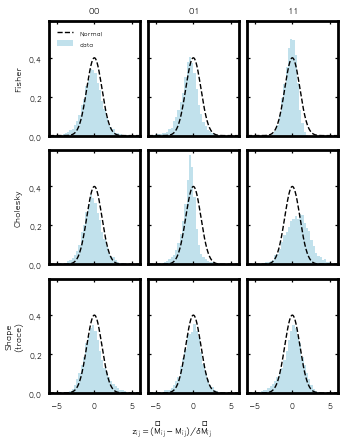

In [118]:
fig, axes = plot_predictive_histogram_grid(
    ensemble_F_predictions=ensemble_F_predictions,
    F_true_out=F_true_out,
    ensemble_weights=ensemble_weights,
    shape_norm=shape_norm,   # "trace" or "correlation"
    filename="all_histograms_grid2.pdf",
    fig_width=3.41,
)

In [21]:
def plot_predictive_histogram_grid_tworows(
    ensemble_F_predictions,
    F_true_out,
    ensemble_weights,
    shape_norm="trace",
    filename="predictive_histogram_grid.pdf",
    fig_width=3.35,          # single-column width in many paper templates
    bins=np.linspace(-6, 6, 41),
    dpi=400,
    show=True,
):
    """
    Plot a compact 3x3 grid of standardized-residual histograms.

    Rows:
        1. Fisher
        2. Cholesky
        3. Shape-normalized Fisher

    Columns:
        [0,0], [0,1], [1,1]

    Parameters
    ----------
    ensemble_F_predictions : array, shape [n_models, n_samples, 2, 2]
        Ensemble Fisher predictions.
    F_true_out : array, shape [n_samples, 2, 2]
        True Fisher matrices.
    ensemble_weights : array
        Weights used for ensemble averaging/std, same as in your notebook.
    shape_norm : {"trace", "correlation"}
        Shape normalization used for the third row.
    filename : str or None
        Output filename. If None, figure is not saved.
    fig_width : float
        Figure width in inches; 3.35 is a typical single-column width.
    dpi : int
        Save resolution.
    show : bool
        Whether to call plt.show().
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import jax
    import jax.numpy as jnp

    def _safe_weighted_stats(F_ensemble, weights):
        F_avg = jnp.average(F_ensemble, axis=0, weights=weights)
        F_std = weighted_std(F_ensemble, weights=weights, axis=0)
        return F_avg, F_std

    def _upper_cholesky(A):
        # Robust across JAX versions: use lower-triangular cholesky and transpose
        # so we still plot the (0,1) entry like your original code intended.
        return jnp.swapaxes(jnp.linalg.cholesky(A), -1, -2)

    def _shape_normalize(F_ensemble, F_true, mode):
        if mode == "correlation":
            F_ensemble = jax.vmap(jax.vmap(normalize_to_correlation))(F_ensemble)
            F_true = jax.vmap(normalize_to_correlation)(F_true)
            row_label = "Shape\n(corr.)"
        elif mode == "trace":
            F_ensemble = jax.vmap(jax.vmap(normalize_by_trace))(F_ensemble)
            F_true = jax.vmap(normalize_by_trace)(F_true)
            row_label = "Shape\n(trace)"
        else:
            raise ValueError("shape_norm must be 'trace' or 'correlation'")
        return F_ensemble, F_true, row_label

    def _zscore(pred_mean, pred_std, truth, i, j, abs_offdiag=False, eps=1e-12):
        mu_pred = np.asarray(pred_mean[:, i, j])
        mu_std  = np.asarray(pred_std[:, i, j])
        mu_true = np.asarray(truth[:, i, j])

        if abs_offdiag and (i != j):
            mu_pred = np.abs(mu_pred)
            mu_true = np.abs(mu_true)

        z = (mu_pred - mu_true) / np.maximum(mu_std, eps)
        z = z[np.isfinite(z)]
        return z

    # --- Build the 3 rows ---
    fisher_ens = ensemble_F_predictions
    fisher_true = F_true_out
    fisher_avg, fisher_std = _safe_weighted_stats(fisher_ens, ensemble_weights)

    chol_ens = _upper_cholesky(ensemble_F_predictions)
    chol_true = _upper_cholesky(F_true_out)
    chol_avg, chol_std = _safe_weighted_stats(chol_ens, ensemble_weights)

    shape_ens, shape_true, shape_row_label = _shape_normalize(
        ensemble_F_predictions, F_true_out, shape_norm
    )
    shape_avg, shape_std = _safe_weighted_stats(shape_ens, ensemble_weights)

    rows = [
        # ("Fisher", fisher_avg, fisher_std, fisher_true, True),
        ("Cholesky", chol_avg, chol_std, chol_true, True),
        (shape_row_label, shape_avg, shape_std, shape_true, False),
    ]

    components = [(0, 0), (0, 1), (1, 1)]
    col_titles = [r"$00$", r"$01$", r"$11$"]

    # Compact height for a single-column figure
    # fig_height = fig_width * 1.55
    fig_height = fig_width * 0.88
    fig, axes = plt.subplots(
        2, 3,
        figsize=(fig_width, fig_height),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    # Reference standard-normal curve
    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)

    for r, (row_name, F_avg, F_std, F_true, abs_offdiag) in enumerate(rows):
        for c, (i, j) in enumerate(components):
            ax = axes[r, c]
            z = _zscore(F_avg, F_std, F_true, i, j, abs_offdiag=abs_offdiag)

            ax.plot(xpdf, ypdf, lw=1.0, label="Normal", c='k', ls='--')
            ax.hist(z, bins=bins, density=True, alpha=0.75, label="data", color='lightblue')

            if r == 0:
                ax.set_title(col_titles[c], fontsize=8)

            if c == 0:
                ax.set_ylabel(row_name, fontsize=8)

            ax.tick_params(axis="both", labelsize=7, length=2)
            ax.set_xlim(bins[0], bins[-1])

    # One legend only
    axes[0, 0].legend(frameon=False, fontsize=6, loc="best")

    fig.supxlabel(
        r"$z_{ij} = (\hat{M}_{ij} - M_{ij}) / \delta \hat{M}_{ij}$",
        fontsize=8
    )

    # fig.suptitle("Predictive plot by component", fontsize=7)

    if filename is not None:
        if not filename.endswith((".png", ".pdf", ".jpg", ".svg")):
            filename = filename + ".pdf"
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
        print(f"Saved histogram grid to: {filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved histogram grid to: two_histograms_grid2.pdf


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


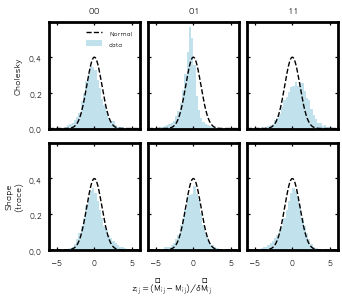

In [13]:
fig, axes = plot_predictive_histogram_grid_tworows(
    ensemble_F_predictions=ensemble_F_predictions,
    F_true_out=F_true_out,
    ensemble_weights=ensemble_weights,
    shape_norm=shape_norm,   # "trace" or "correlation"
    filename="two_histograms_grid2.pdf",
    fig_width=3.41,
)

In [8]:
results_flattening = np.load("ex_rosen_31_03/rosenbrock_Sigma1_2.npz")

# etas_to_plot = 

In [9]:
# Import preprocessing (rotations, data loading)
from degeneracy_distillery.preprocessing_utils import (
    load_and_process_data,
    process_ensemble_rotation,
    flatten_with_numerical_jacobian,
    batch_flatten_fisher,
    rotate_coords,
    load_and_process_data,
    weighted_std
)

In [10]:
# Option 1: Load and process in one call
data = load_and_process_data(
    datapath="",
    filename="ex_rosen_31_03/rosenbrock_Sigma1_2.npz",
    num_samps=5000,
    process_ensemble=True,  # <-- enables full processing
    verbose=False,
    y_reference_index=None,
    apply_varimax=True,           # Enable Jacobian sparsity
    varimax_method="varimax",     # or "quartimax"
    jacobian_sparsity="norm",      # or "flatten" or "variance"
    use_var=False,
    restore_reference_mean=False,
)

# Access results directly:
y = data['y']           # Weighted average outputs (masked)
y_std = data['y_std']   # Weighted std (masked)
dy = data['dy']         # Weighted average Jacobian (masked)
dy_sr = data['dy_sr']   # Weighted average rotated Jacobian
Fs = data['Fs']         # Weighted average Fisher
X = data['X']           # Parameters (masked)

norm_factor = data['norm_factor']

n_params = X.shape[-1]

print("num significant var components", (dy_sr.var(0) > (dy_sr.var(0).mean())).sum())

Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetastar [-0.02084756  0.00268793]
Applied Jacobian-sparsity rotation to y_reference (aggregate=norm)
thetas

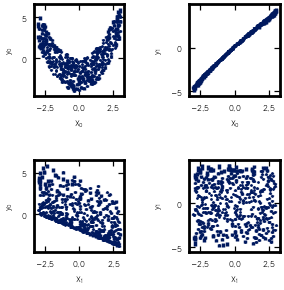

In [11]:
fig, axs = plt.subplots(n_params, n_params, figsize=(3.41,3.41))

skip=10

for i in range(X.shape[-1]):
    for j in range(y.shape[-1]):

        # row, column
        axs[i,j].errorbar(X[::skip,i], y[::skip, j], yerr=y_std[::skip, j], label='', fmt='o', markersize=1)

        axs[i,j].set_xlabel(r"$X_%d$"%(i), fontsize=7)
        axs[i,j].set_ylabel(r"$y_%d$"%(j), fontsize=7)
        axs[i,j].tick_params(axis="both", labelsize=7)

plt.tight_layout()
plt.show()

In [107]:
bins

array([-6. , -5.7, -5.4, -5.1, -4.8, -4.5, -4.2, -3.9, -3.6, -3.3, -3. ,
       -2.7, -2.4, -2.1, -1.8, -1.5, -1.2, -0.9, -0.6, -0.3,  0. ,  0.3,
        0.6,  0.9,  1.2,  1.5,  1.8,  2.1,  2.4,  2.7,  3. ,  3.3,  3.6,
        3.9,  4.2,  4.5,  4.8,  5.1,  5.4,  5.7,  6. ])

Font 'rm' does not have a glyph for '\\langle' [U+27e8], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\rangle' [U+27e9], substituting with a dummy symbol.
/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/pyparsing/core.py:287: UserWarning: Glyph 164 (\N{CURRENCY SIGN}) missing from font(s) HersheySimplex.
  return func(*args[limit:])
Font 'rm' does not have a glyph for '\\langle' [U+27e8], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\rangle' [U+27e9], substituting with a dummy symbol.


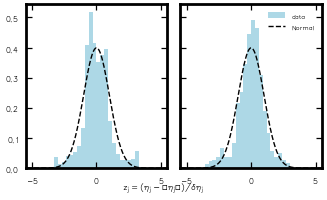

In [120]:
fig,axs = plt.subplots(1,n_params, figsize=(3.41, 3.41 * 0.6),
                      sharex=True, sharey=True)
axs = axs.flatten()

bins=np.linspace(-6, 6, 41)

xpdf = np.linspace(bins[0], bins[-1], 400)
ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)



for i,ax in enumerate(axs):
    ax.hist(((data['ys'] - y) / y_std)[:, :, i].flatten(), density=True, 
            label='data',
            bins=bins, color='lightblue')
    ax.plot(xpdf, ypdf, lw=1.0, label="Normal", c='k', ls='--')
    # ax.hist(np.random.normal(size=(2000,)).flatten(), histtype='step', density=True)
    ax.set_xlim(-5.5, 5.5)
    ax.tick_params(axis="both", labelsize=7)
    # ax.set_xlabel(r"$({\eta_%d} - \langle \eta_%d \rangle) / \delta \eta_%d$"%(i,i,i),
    #              fontsize=8)

plt.tight_layout()
fig.supxlabel(
    r"$z_{j} = ({\eta}_j - \langle \eta_j \rangle) / \delta \eta_j$",
    fontsize=8,
    
)
plt.legend(frameon=False, fontsize=6)
# plt.suptitle('', fontsize=7)
# plt.savefig("eta_histograms.pdf", dpi=400)


In [20]:
eta_z = ((data["ys"] - y) / y_std)

fig, axes = plot_histogram_grid_with_eta(
    ensemble_F_predictions=ensemble_F_predictions,
    F_true_out=F_true_out,
    ensemble_weights=ensemble_weights,
    eta_z=eta_z,
    shape_norm="trace",   # "trace" or "correlation"
    filename="cholesky_shape_eta_histograms2.pdf",
    fig_width=3.41,
)

NameError: name 'plot_histogram_grid_with_eta' is not defined

In [121]:
def plot_histogram_grid_with_eta(
    ensemble_F_predictions,
    F_true_out,
    ensemble_weights,
    eta_z,
    shape_norm="trace",
    filename="histogram_grid_with_eta.pdf",
    fig_width=3.41,
    bins=np.linspace(-6, 6, 41),
    dpi=400,
    show=True,
):
    """
    3-row histogram figure:

      Row 1: Fisher Cholesky components  [00, 01, 11]
      Row 2: Fisher shape components     [00, 01, 11]
      Row 3: eta components              [eta_0, eta_1]

    Top two rows:
        standardized residuals relative to TRUE matrix components

    Bottom row:
        standardized eta values, compared to a unit Gaussian

    Bottom row has 2 stretched panels.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from matplotlib.gridspec import GridSpec
    from matplotlib.lines import Line2D
    import jax
    import jax.numpy as jnp

    def _upper_cholesky(A):
        return jnp.swapaxes(jnp.linalg.cholesky(A), -1, -2)

    def _matrix_stats(F_ensemble, weights):
        F_avg = jnp.average(F_ensemble, axis=0, weights=weights)
        F_std = weighted_std(F_ensemble, weights=weights, axis=0)
        return F_avg, F_std

    def _shape_normalize(F_ensemble, F_true, mode):
        if mode == "correlation":
            F_ensemble = jax.vmap(jax.vmap(normalize_to_correlation))(F_ensemble)
            F_true = jax.vmap(normalize_to_correlation)(F_true)
            row_name = "Shape\n(corr.)"
        elif mode == "trace":
            F_ensemble = jax.vmap(jax.vmap(normalize_by_trace))(F_ensemble)
            F_true = jax.vmap(normalize_by_trace)(F_true)
            row_name = "Shape\n(trace)"
        else:
            raise ValueError("shape_norm must be 'trace' or 'correlation'")
        return F_ensemble, F_true, row_name

    def _matrix_z(F_avg, F_std, F_true, i, j, abs_offdiag=False, eps=1e-12):
        mu_pred = np.asarray(F_avg[:, i, j])
        mu_std  = np.asarray(F_std[:, i, j])
        mu_true = np.asarray(F_true[:, i, j])

        if abs_offdiag and (i != j):
            mu_pred = np.abs(mu_pred)
            mu_true = np.abs(mu_true)

        z = (mu_pred - mu_true) / np.maximum(mu_std, eps)
        return z[np.isfinite(z)]

    # --- data prep ---
    chol_ens = ensemble_F_predictions #_upper_cholesky(ensemble_F_predictions)
    chol_true = F_true_out #_upper_cholesky(F_true_out)
    chol_avg, chol_std = _matrix_stats(chol_ens, ensemble_weights)

    shape_ens, shape_true, shape_row_name = _shape_normalize(
        ensemble_F_predictions, F_true_out, shape_norm
    )
    shape_avg, shape_std = _matrix_stats(shape_ens, ensemble_weights)

    eta_z = np.asarray(eta_z).reshape(-1, np.asarray(eta_z).shape[-1])
    if eta_z.shape[-1] < 2:
        raise ValueError("eta_z must have at least 2 components in the last axis.")

    xpdf = np.linspace(bins[0], bins[-1], 400)
    ypdf = np.exp(-0.5 * xpdf**2) / np.sqrt(2.0 * np.pi)

    fig_height = fig_width * 1.5
    fig = plt.figure(figsize=(fig_width, fig_height), constrained_layout=False)
    gs = GridSpec(3, 6, figure=fig)

    # Top row
    ax00 = fig.add_subplot(gs[0, 0:2])
    ax01 = fig.add_subplot(gs[0, 2:4], sharex=ax00, sharey=ax00)
    ax11 = fig.add_subplot(gs[0, 4:6], sharex=ax00, sharey=ax00)

    # Middle row
    axs00 = fig.add_subplot(gs[1, 0:2], sharex=ax00, sharey=ax00)
    axs01 = fig.add_subplot(gs[1, 2:4], sharex=ax00, sharey=ax00)
    axs11 = fig.add_subplot(gs[1, 4:6], sharex=ax00, sharey=ax00)

    # Bottom row
    axe0 = fig.add_subplot(gs[2, 0:3], sharex=ax00, sharey=ax00)
    axe1 = fig.add_subplot(gs[2, 3:6], sharex=ax00, sharey=ax00)

    def _style_ax(ax, show_xlabels=False, show_ylabels=False):
        ax.plot(xpdf, ypdf, lw=1.0, c="k", ls="--", label="Normal")
        ax.set_xlim(-5.5, 5.5)
        ax.tick_params(axis="both", labelsize=7, length=2, pad=1.5)

        if not show_xlabels:
            ax.tick_params(labelbottom=False)
        if not show_ylabels:
            ax.tick_params(labelleft=False)

    # --- Row 1: Cholesky ---
    chol_axes = [ax00, ax01, ax11]
    chol_comps = [(0, 0), (0, 1), (1, 1)]
    chol_titles = [r"$F_{00}$", r"$F_{01}$", r"$F_{11}$"]

    for k, (ax, (i, j), title) in enumerate(zip(chol_axes, chol_comps, chol_titles)):
        z = _matrix_z(chol_avg, chol_std, chol_true, i, j, abs_offdiag=True)
        ax.hist(z, density=True, bins=bins, color="lightblue", alpha=0.8, label="data")
        _style_ax(ax, show_xlabels=False, show_ylabels=(k == 0))
        ax.set_title(title, fontsize=8, pad=2.5)

    ax00.set_ylabel("Fisher", fontsize=8, labelpad=6)

    # --- Row 2: Shape ---
    shape_axes = [axs00, axs01, axs11]
    shape_comps = [(0, 0), (0, 1), (1, 1)]
    shape_titles = [r"$F_{00}$", r"$F_{01}$", r"$F_{11}$"]

    for k, (ax, (i, j), title) in enumerate(zip(shape_axes, shape_comps, shape_titles)):
        z = _matrix_z(shape_avg, shape_std, shape_true, i, j, abs_offdiag=False)
        ax.hist(z, density=True, bins=bins, color="lightblue", alpha=0.8, label="data")
        _style_ax(ax, show_xlabels=False, show_ylabels=(k == 0))
        ax.set_title(title, fontsize=8, pad=2.5)

    axs00.set_ylabel(shape_row_name, fontsize=8, labelpad=6)

    # --- Row 3: eta ---
    eta_axes = [axe0, axe1]
    eta_titles = [r"$\eta_0$", r"$\eta_1$"]

    for k, (ax, title) in enumerate(zip(eta_axes, eta_titles)):
        z = eta_z[:, k]
        z = z[np.isfinite(z)]
        ax.hist(z, density=True, bins=bins, color="lightblue", alpha=0.8, label="data")
        _style_ax(ax, show_xlabels=True, show_ylabels=(k == 0))
        ax.set_title(title, fontsize=8, pad=2.5)

    axe0.set_ylabel(r"$\eta$", fontsize=8, labelpad=6)

    # Legend once
    # ax00.legend(frameon=False, fontsize=6, loc="upper left")

    # separate legend for eta components
    axe0.legend(frameon=False, fontsize=6, loc="upper left")

    # Manual spacing
    fig.align_ylabels([ax00, axs00, axe0])
    fig.subplots_adjust(
        left=0.14,
        right=0.985,
        bottom=0.11,
        top=0.96,
        wspace=0.30,
        hspace=0.50,
    )

    # --- Separator + semantic labels ---
    # Positions in figure coordinates
    pos_mid = axs00.get_position()
    pos_bot = axe0.get_position()

    # Put separator halfway between row 2 and row 3
    sep_y = 0.5 * (pos_mid.y0 + pos_bot.y1)

    # Horizontal dividing line
    fig.add_artist(
        Line2D(
            [0.14, 0.985],
            [sep_y, sep_y],
            transform=fig.transFigure,
            color="0.55",
            lw=0.8,
        )
    )

    # Label for first two rows: unbiased wrt true matrix components
    fig.text(
        0.56,
        sep_y + 0.010,
        r"matrix components: $z_{ij} = (\hat{M}_{ij} - M^{\rm true}_{ij})/\delta \hat{M}_{ij}$",
        ha="center",
        va="bottom",
        fontsize=7.5,
    )

    # Bottom-row label: eta Gaussianity
    fig.text(
        0.56,
        0.035,
        r"flat components: $z_j = (\eta_j -  <{\eta}_j>)/\delta \eta_j$",
        ha="center",
        va="bottom",
        fontsize=8,
    )

    if filename is not None:
        if not filename.endswith((".png", ".pdf", ".jpg", ".svg")):
            filename = filename + ".pdf"
        fig.savefig(filename, dpi=dpi, bbox_inches="tight")
        print(f"Saved histogram grid to: {filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, {
        "cholesky": [ax00, ax01, ax11],
        "shape": [axs00, axs01, axs11],
        "eta": [axe0, axe1],
    }

Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.
Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


Saved histogram grid to: cholesky_shape_eta_histograms.pdf


Font 'rm' does not have a glyph for '\\circumflexaccent' [U+302], substituting with a dummy symbol.


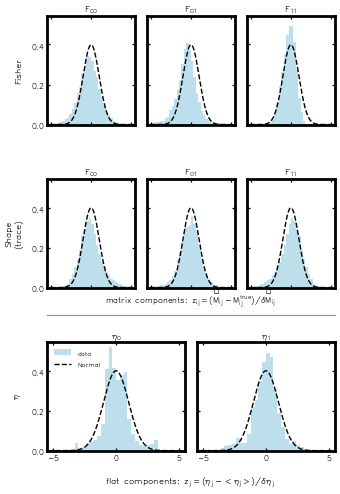

In [122]:
eta_z = ((data["ys"] - y) / y_std)

fig, axes = plot_histogram_grid_with_eta(
    ensemble_F_predictions=ensemble_F_predictions,
    F_true_out=F_true_out,
    ensemble_weights=ensemble_weights,
    eta_z=eta_z,
    shape_norm="trace",   # "trace" or "correlation"
    filename="cholesky_shape_eta_histograms.pdf",
    fig_width=3.41,
)

In [14]:
import pickle

def save_obj(obj, name):
    with open(f'{name}.pkl', 'wb') as f:
        pickle.dump(obj, f)

def load_obj(name):
    with open(f'{name}', 'rb') as f:
        return pickle.load(f)

analysis = load_obj("ex_rosen_31_03/sr_analysis.pkl")
split_data = np.load("ex_rosen_31_03/split_data.npz")

n_params=2

# Access test data for further analysis
X_test = split_data['X_test']
y_test = split_data['y_test']
Fs_test = split_data['Fs_test']
y_std_test = split_data['y_std_test']
dy_sr_test = split_data['dy_sr_test']


from degeneracy_distillery.sr_utils import fit_and_analyze_sr, analyze_equations


mdl_coords, frob_coords, _ = analyze_equations(
    X_test, y_test, y_std_test, dy_sr_test, Fs_test,
    parent_dir="ex_rosen_31_03/",
    n_params=n_params,
    equation_set='pareto',
    max_complexity_thresh=20,
)


Analysing component 1 of 2 (index 0)
Loading equations from: pareto.csv
7 equations below complexity threshold 20


Component 1: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:11<00:00,  1.59s/it]



Best MDL equation (complexity=10):
  (2.331208 + (0.914443 * ((((0.849230 * X1) ^ 2) + ((-0.737988) * X2)) + (0.149706 * X1))))
  LaTeX: $b_{0} + b_{1} \left(X_{1}^{2} b_{2}^{2} + X_{1} b_{4} + X_{2} b_{3}\right)$

Best Frob loss equation (complexity=14):
  (0.000191 + (0.999964 * ((((-0.674341) * X2) + ((0.819911 * X1) ^ 2)) + sqrt(sqrt((29.406542 + (6.474593 * X1)))))))
  LaTeX: $b_{0} + b_{1} \left(X_{1}^{2} b_{3}^{2} + X_{2} b_{2} + \left(X_{1} b_{5} + b_{4}\right)^{0.25}\right)$

Analysing component 2 of 2 (index 1)
Loading equations from: pareto.csv
9 equations below complexity threshold 20


Component 2: 100%|████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:03<00:00,  2.52it/s]


Best MDL equation (complexity=13):
  (0.000000 + (0.999999 * (exp(exp(((-0.038174) * X1))) * ((0.523949 * X1) + (0.067393 + (0.018387 * X2))))))
  LaTeX: $b_{0} + b_{1} \left(X_{1} b_{3} + X_{2} b_{5} + b_{4}\right) e^{e^{X_{1} b_{2}}}$

Best Frob loss equation (complexity=14):
  ((-0.000002) + (0.999999 * ((exp((0.108703 * X1)) + ((-0.149438) * X1)) * ((0.050317 * X2) + (0.181631 + (1.391545 * X1))))))
  LaTeX: $b_{0} + b_{1} \left(X_{1} b_{3} + e^{X_{1} b_{2}}\right) \left(X_{1} b_{6} + X_{2} b_{4} + b_{5}\right)$


In [50]:
def plot_symbolic_tradeoff_side_by_side(
    analysis,
    n_components=2,
    figwidth=7.0,   # good starting point for two-column width
    filename="symbolic_tradeoff_side_by_side.pdf",
    max_complexity_thresh=None,
    show=True,
):
    """
    Plot a two-column, side-by-side tradeoff figure for symbolic equations.

    Each panel shows, for one component:
      - left y-axis: change in negative log-likelihood
      - right y-axis: change in Frobenius norm loss
      - vertical lines at the best-MDL and best-Frobenius equations
    """
    import numpy as np
    import matplotlib.pyplot as plt

    n_components = min(n_components, 2)
    cm = plt.get_cmap("Set1")

    figheight = figwidth * 0.42
    fig, axs = plt.subplots(
        1, n_components,
        figsize=(figwidth, figheight),
        sharex=False,
        constrained_layout=False,
    )

    if n_components == 1:
        axs = [axs]

    twin_axes = []

    for i, ax1 in enumerate(axs):
        ax2 = ax1.twinx()
        twin_axes.append(ax2)

        complexity = np.asarray(analysis["complexity"][i])
        logL = np.asarray(analysis["logL"][i])
        frobloss = np.asarray(analysis["frobloss"][i])
        pareto_latex = analysis["latex"][i]

        ibest_mdl = int(analysis["ibest_mdl"][i])
        ibest_frob = int(analysis["ibest_frob"][i])

        if max_complexity_thresh is not None:
            mask = complexity <= max_complexity_thresh
        else:
            mask = np.ones_like(complexity, dtype=bool)

        x = complexity[mask]
        y1 = logL[mask]
        y2 = frobloss[mask]

        # Main curves
        ax1.plot(
            x, y1,
            marker=".", linestyle="-", color=cm(0),
            markersize=4, lw=0.9
        )
        ax2.plot(
            x, y2,
            marker=".", linestyle=":", color=cm(1),
            markersize=4, lw=0.9
        )

        # Best-equation markers
        ax1.axvline(
            complexity[ibest_mdl],
            color=cm(3),
            ls="--",
            lw=1.0,
            label=rf"MDL: ${pareto_latex[ibest_mdl]}$",
        )
        ax1.axvline(
            complexity[ibest_frob],
            color=cm(4),
            ls="--",
            lw=1.0,
            label=rf"Frob: ${pareto_latex[ibest_frob]}$",
        )

        # Scales
        ax1.set_yscale("symlog")
        ax2.set_yscale("symlog")
        ax1.set_ylim(bottom=0)
        ax2.set_ylim(bottom=0)

        # Labels
        ax1.set_xlabel("Complexity", fontsize=8, labelpad=3)
        ax1.set_title(f"component {i + 1}", fontsize=8, pad=2.5)

        # Left y-axis only on left panel
        if i == 0:
            ax1.set_ylabel(r"$\Delta$ NLL", fontsize=8, color=cm(0), labelpad=4)
            ax1.tick_params(axis="y", labelsize=7, colors=cm(0), pad=1.5, length=2)
            ax1.spines["left"].set_color(cm(0))
        else:
            ax1.set_ylabel("")
            ax1.tick_params(axis="y", labelleft=False, colors=cm(0), length=2)
            ax1.spines["left"].set_color(cm(0))

        # Right y-axis on both panels, since each panel has its own twin axis
        ax2.set_ylabel(r"$\Delta || \cdot ||_\mathcal{F}$", fontsize=8, color=cm(1), labelpad=4)
        ax2.tick_params(axis="y", labelsize=7, colors=cm(1), pad=1.5, length=2)
        ax2.spines["right"].set_color(cm(1))

        ax1.yaxis.label.set_color(cm(0))
        ax2.yaxis.label.set_color(cm(1))
        ax1.tick_params(axis="x", labelsize=7, pad=1.5, length=2)

        # Limits
        if max_complexity_thresh is not None:
            ax1.set_xlim(x.min(), max_complexity_thresh)

        # ax1.axvline(complexity[ibest_mdl], color=cm(3), ls="--", lw=1.0, label="MDL best")
        # ax1.axvline(complexity[ibest_frob], color=cm(4), ls="--", lw=1.0, label="Frob best")

        # Compact legend
        ax1.legend(
            frameon=False,
            fontsize=6,
            loc="best",
            handlelength=1.3,
            borderpad=0.2,
            labelspacing=0.25,
        )

    fig.subplots_adjust(
        left=0.09,
        right=0.96,
        bottom=0.18,
        top=0.90,
        wspace=0.38,
    )

    if filename is not None:
        if not filename.endswith((".png", ".pdf", ".jpg", ".svg")):
            filename = filename + ".pdf"
        fig.savefig(filename, dpi=400, bbox_inches="tight")
        print(f"Saved side-by-side plot to: {filename}")

    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axs, twin_axes

1 extra bytes in post.stringData array


Saved side-by-side plot to: symbolic_tradeoff_side_by_side.pdf


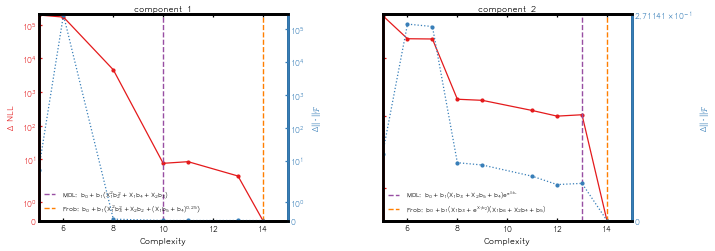

In [35]:
fig, axs, twin_axes = plot_symbolic_tradeoff_side_by_side(
    analysis,
    n_components=2,
    figwidth=3.41 * 2,
    filename="symbolic_tradeoff_side_by_side.pdf",
    max_complexity_thresh=15,
)

In [36]:
def make_front_table_two_components(
    analysis,
    components=(0, 1),
    include_equation=True,
    frob_key="frobloss",
    mdl_key="complexity",
    latex_key="latex",
    caption="Symbolic Pareto fronts for two components, ordered by MDL complexity.",
    label="tab:front_two_components",
    fontsize="\\footnotesize",
    table_env="table*",
    use_booktabs=True,
):
    """
    Build a LaTeX table showing the full front for two components side-by-side,
    ordered by MDL complexity.

    Parameters
    ----------
    analysis : dict
        Expected keys:
          - analysis[mdl_key][i]
          - analysis[frob_key][i]
          - analysis[latex_key][i]
    components : tuple[int, int]
        The two component indices to compare, e.g. (0, 1).
    include_equation : bool
        If True, include an equation column for each component.
        If False, output only MDL and Frob columns, matching your sketch.
    frob_key : str
        Key for Frobenius loss values in `analysis`.
    mdl_key : str
        Key for MDL/complexity values in `analysis`.
    latex_key : str
        Key for LaTeX equations in `analysis`.
    caption : str
        LaTeX caption.
    label : str
        LaTeX label.
    fontsize : str
        LaTeX size command.
    table_env : str
        Usually "table" or "table*".
    use_booktabs : bool
        Whether to use booktabs rules.

    Returns
    -------
    latex_str : str
        The LaTeX table as a string.
    """

    c1, c2 = components

    def _rows_for_component(i):
        mdl_vals = list(analysis[mdl_key][i])
        frob_vals = list(analysis[frob_key][i])
        eqs = list(analysis[latex_key][i])

        rows = [
            {"mdl": mdl, "frob": frob, "eq": eq}
            for mdl, frob, eq in zip(mdl_vals, frob_vals, eqs)
        ]
        rows.sort(key=lambda r: r["mdl"])
        return rows

    rows1 = _rows_for_component(c1)
    rows2 = _rows_for_component(c2)
    nrows = max(len(rows1), len(rows2))

    def _fmt_num(x):
        try:
            x = float(x)
            if x == 0:
                return "0"
            if abs(x) >= 100 or abs(x) < 1e-2:
                return f"{x:.2e}"
            return f"{x:.3f}"
        except Exception:
            return str(x)

    def _get_row(rows, j):
        if j < len(rows):
            r = rows[j]
            if include_equation:
                return [_fmt_num(r["mdl"]), _fmt_num(r["frob"]), f"${r['eq']}$"]
            return [_fmt_num(r["mdl"]), _fmt_num(r["frob"])]
        else:
            if include_equation:
                return ["", "", ""]
            return ["", ""]

    if use_booktabs:
        top = "\\toprule"
        mid = "\\midrule"
        bot = "\\bottomrule"
        note = "% requires \\usepackage{booktabs}"
    else:
        top = mid = bot = "\\hline"
        note = ""

    if include_equation:
        colspec = "r r p{0.22\\textwidth} r r p{0.22\\textwidth}"
        header1 = (
            f"\\multicolumn{{3}}{{c}}{{component {c1 + 1}}} & "
            f"\\multicolumn{{3}}{{c}}{{component {c2 + 1}}} \\\\"
        )
        header2 = "MDL & Frob & Equation & MDL & Frob & Equation \\\\"
    else:
        colspec = "r r r r"
        header1 = (
            f"\\multicolumn{{2}}{{c}}{{component {c1 + 1}}} & "
            f"\\multicolumn{{2}}{{c}}{{component {c2 + 1}}} \\\\"
        )
        header2 = "MDL & Frob & MDL & Frob \\\\"

    lines = []
    if note:
        lines.append(note)

    lines.extend([
        f"\\begin{{{table_env}}}[t]",
        "\\centering",
        fontsize,
        f"\\begin{{tabular}}{{{colspec}}}",
        top,
        header1,
        mid,
        header2,
        mid,
    ])

    for j in range(nrows):
        row = _get_row(rows1, j) + _get_row(rows2, j)
        lines.append(" & ".join(row) + " \\\\")

    lines.extend([
        bot,
        "\\end{tabular}",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        f"\\end{{{table_env}}}",
    ])

    latex_str = "\n".join(lines)
    print(latex_str)
    return latex_str

In [217]:
latex_table = make_front_table_two_components(
    analysis,
    components=(0, 1),
    include_equation=True,
    caption="Full Pareto fronts for components 1 and 2, ordered by MDL complexity.",
    label="tab:pareto_fronts_side_by_side",
)

% requires \usepackage{booktabs}
\begin{table*}[t]
\centering
\footnotesize
\begin{tabular}{r r p{0.22\textwidth} r r p{0.22\textwidth}}
\toprule
\multicolumn{3}{c}{component 1} & \multicolumn{3}{c}{component 2} \\
\midrule
MDL & Frob & Equation & MDL & Frob & Equation \\
\midrule
5.000 & 0.472 & $X_{1} b_{1} b_{2} + b_{0}$ & 5.000 & 5.379 & $X_{2} b_{1} b_{2} + b_{0}$ \\
7.000 & 1.551 & $b_{0} + b_{1} b_{2}^{X_{1} b_{3}}$ & 6.000 & 1.09e+04 & $b_{0} + b_{1} e^{X_{1} b_{2}}$ \\
8.000 & 1.286 & $b_{0} + b_{1} \left(X_{1} b_{3} + e^{X_{1} b_{2}}\right)$ & 7.000 & 8.06e+04 & $X_{1}^{2} b_{1} b_{2} b_{3} + b_{0}$ \\
9.000 & 1.318 & $b_{0} + b_{1} \left(X_{1} b_{3} + e^{e^{X_{1} b_{2}}}\right)$ & 8.000 & 1.652 & $b_{0} + b_{1} \left(X_{2} b_{3} + e^{X_{1} b_{2}}\right)$ \\
10.000 & 0.401 & $b_{0} + b_{1} \left(X_{1} b_{4} + e^{X_{1} b_{3} + X_{2} b_{2}}\right)$ & 9.000 & 0.366 & $b_{0} + b_{1} \left(X_{1}^{2} b_{3} b_{4} + X_{2} b_{2}\right)$ \\
11.000 & 0 & $b_{0} + b_{1} \left(X_{1} b_{4}

In [12]:
from degeneracy_distillery.postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
    get_Q_jax, construct_M,
    postprocess_eqs,
    # analyze_equations

)

from degeneracy_distillery.preprocessing_utils import get_eigenvalues as get_evalues

In [52]:
mdl_coords

['(2.331208 + (0.914443 * ((((0.849230 * X1) ^ 2) + ((-0.737988) * X2)) + (0.149706 * X1))))',
 '(0.000000 + (0.999999 * (exp(exp(((-0.038174) * X1))) * ((0.523949 * X1) + (0.067393 + (0.018387 * X2))))))']

In [16]:
# One-liner with all options
pruned_exprs, consts, A_opt = postprocess_eqs(
    coordinates=mdl_coords,
    X=X_test, Fs=Fs_test, n_params=n_params,
    optimize_rotation="none",
    rotation_params={
        # "lambda_sparse": 0.5,
        # "lambda_flat": 10.0,
        "maxiter": 500
    },
    threshold=0.5,
    prune_constants=True,
    remove_floats=False
)

Parsing 2 symbolic expressions...
Found 11 total parameters (9 linear)

Starting pruning with threshold=0.5...
initial flattening score: 0.355018
computing importance scores for all coefficients...
Importance scores - min: 0.000000e+00, max: 7.651147e+00, median: 0.000000e+00


pruning coefficients:  33%|██████████████████▋                                     | 3/9 [00:00<00:00,  6.76it/s, removed=2, delta=0.086440]

coeff (0,2) - importance 0.000000e+00: delta 919383.687500 exceeds threshold, keeping


pruning coefficients:  56%|███████████████████████████████                         | 5/9 [00:00<00:00,  9.85it/s, removed=2, delta=0.086440]

coeff (1,2) - importance 0.000000e+00: delta 1180836.125000 exceeds threshold, keeping
zeroing coeff (1,1) caused error - keeping it


...

zeroing coeff (0,1) caused error - keeping it

pruning summary: removed 4/9 coefficients

--- Second pass: pruning all constants (including nonlinear) ---
Pruning all constants (including nonlinear)
Reference flattening score: 0.464726
Found 4 total constants across 2 expressions
Computing importance scores...


Scoring: 100%|████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 15.16it/s]


Importance scores - min: 1.841313e-01, max: 1.074878e+00, median: 7.147785e-01


Pruning: 100%|███████████████████████████████████████████████| 4/4 [00:00<00:00, 28.00it/s, removed=1, expr=1, val=-0.0380, delta=-0.223016]

Error zeroing const 0.5240 in expr 1: jacrev requires real-valued outputs (output dtype that is a sub-dtype of np.floating), but got int32. For differentiation of functions with integer outputs, use jax.vjp directly.

Constant pruning summary: removed 1/4 constants

Postprocessing complete!
Input expressions: 2
Output expressions: 2


In [17]:
pruned_exprs

['0.659*X1**2 - 0.675*X2', '0.524*E*X1']

In [112]:
# One-liner with all options
pruned_exprs_frob, consts, A_opt = postprocess_eqs(
    coordinates=frob_coords,
    X=X_test, Fs=Fs_test, n_params=n_params,
    optimize_rotation="none",
    rotation_params={
        # "lambda_sparse": 0.5,
        # "lambda_flat": 10.0,
        "maxiter": 500
    },
    threshold=0.5,
    prune_constants=True,
    remove_floats=False
)

Parsing 2 symbolic expressions...
Found 13 total parameters (9 linear)

Starting pruning with threshold=0.5...
initial flattening score: 0.317009
computing importance scores for all coefficients...
Importance scores - min: 0.000000e+00, max: 0.000000e+00, median: 0.000000e+00


pruning coefficients:  22%|██████████▍                                    | 2/9 [00:00<00:01,  5.26it/s, removed=1, delta=0.000000]

zeroing coeff (0,1) caused error - keeping it


pruning coefficients:  33%|███████████████▋                               | 3/9 [00:00<00:01,  4.73it/s, removed=1, delta=0.000000]

coeff (0,2) - importance 0.000000e+00: delta 102054.335938 exceeds threshold, keeping


...

zeroing coeff (1,5) caused error - keeping it

pruning summary: removed 4/9 coefficients

--- Second pass: pruning all constants (including nonlinear) ---
Pruning all constants (including nonlinear)
Reference flattening score: 0.432953
Found 9 total constants across 2 expressions
Computing importance scores...


Scoring: 100%|███████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:00<00:00, 12.33it/s]


Importance scores - min: 1.752794e-02, max: 1.785092e+00, median: 6.550884e-01


Pruning: 100%|███████████████████████████████████████| 9/9 [00:00<00:00, 22.67it/s, removed=1, expr=0, val=6.4750, delta=-0.015926]


Constant pruning summary: removed 1/9 constants

Postprocessing complete!
Input expressions: 2
Output expressions: 2


In [62]:
pruned_exprs_frob

['0.672*X1**2 - 0.674*X2 + 2.32869537370109',
 'X1*(-0.208*X1 + 1.392*exp(0.109*X1))']

In [87]:
mdl_coords

['(2.331208 + (0.914443 * ((((0.849230 * X1) ^ 2) + ((-0.737988) * X2)) + (0.149706 * X1))))',
 '(0.000000 + (0.999999 * (exp(exp(((-0.038174) * X1))) * ((0.523949 * X1) + (0.067393 + (0.018387 * X2))))))']

In [64]:
def make_mdl_frob_equation_table(
    mdl_coords,
    frob_coords,
    caption="Best MDL and Frobenius equations for each component.",
    label="tab:mdl_frob_equations",
    table_env="table",
    fontsize="\\small",
    use_booktabs=True,
    component_names=None,
):
    """
    Build a compact LaTeX table with rows = components and columns = MDL/Frob equations.

    Parameters
    ----------
    mdl_coords : list[str]
        LaTeX equation strings for the MDL-selected equation of each component.
    frob_coords : list[str]
        LaTeX equation strings for the Frob-selected equation of each component.
    caption : str
        Table caption.
    label : str
        LaTeX label.
    table_env : str
        Usually "table" or "table*".
    fontsize : str
        LaTeX font size command, e.g. "\\small" or "\\footnotesize".
    use_booktabs : bool
        Whether to use \\toprule / \\midrule / \\bottomrule.
    component_names : list[str] or None
        Optional row labels. If None, uses "1", "2", ...

    Returns
    -------
    latex_str : str
        The LaTeX table as a string.
    """
    if len(mdl_coords) != len(frob_coords):
        raise ValueError("mdl_coords and frob_coords must have the same length.")

    n = len(mdl_coords)

    if component_names is None:
        component_names = [str(i + 1) for i in range(n)]
    elif len(component_names) != n:
        raise ValueError("component_names must have the same length as mdl_coords.")

    if use_booktabs:
        top = "\\toprule"
        mid = "\\midrule"
        bot = "\\bottomrule"
        note = "% requires \\usepackage{booktabs}"
    else:
        top = mid = bot = "\\hline"
        note = ""

    lines = []
    if note:
        lines.append(note)

    lines.extend([
        f"\\begin{{{table_env}}}[t]",
        "\\centering",
        fontsize,
        "\\begin{tabular}{c p{0.34\\textwidth} p{0.34\\textwidth}}",
        top,
        "Component & MDL equation & Frob equation \\\\",
        mid,
    ])

    for comp, mdl_eq, frob_eq in zip(component_names, mdl_coords, frob_coords):
        mdl_eq = sympy.latex(mdl_eq)
        frob_eq = sympy.latex(frob_eq)
        lines.append(
            f"{comp} & "
            f"${mdl_eq}$ & "
            f"${frob_eq}$ \\\\"
        )

    lines.extend([
        bot,
        "\\end{tabular}",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        f"\\end{{{table_env}}}",
    ])

    latex_str = "\n".join(lines)
    print(latex_str)
    return latex_str

In [66]:
import sympy
latex_table = make_mdl_frob_equation_table(
    mdl_coords=pruned_exprs,
    frob_coords=pruned_exprs_frob,
    caption="MDL- and Frob-selected equations for each component.",
    label="tab:best_eqs",
)

% requires \usepackage{booktabs}
\begin{table}[t]
\centering
\small
\begin{tabular}{c p{0.34\textwidth} p{0.34\textwidth}}
\toprule
Component & MDL equation & Frob equation \\
\midrule
1 & $\mathtt{\text{0.659*X1**2 - 0.675*X2}}$ & $\mathtt{\text{0.672*X1**2 - 0.674*X2 + 2.32869537370109}}$ \\
2 & $\mathtt{\text{0.524*E*X1}}$ & $\mathtt{\text{X1*(-0.208*X1 + 1.392*exp(0.109*X1))}}$ \\
\bottomrule
\end{tabular}
\caption{MDL- and Frob-selected equations for each component.}
\label{tab:best_eqs}
\end{table}


In [67]:
import sympy

In [68]:
sympy.latex(mdl_coords[0])

'\\mathtt{\\text{(2.331208 + (0.914443 * ((((0.849230 * X1) \\textasciicircum 2) + ((-0.737988) * X2)) + (0.149706 * X1))))}}'

In [69]:
pruned_exprs

['0.659*X1**2 - 0.675*X2', '0.524*E*X1']

In [73]:
#@title fisher code
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

def plot_fisher_ellipse(fisher_matrix, mean=None, ax=None, color='blue', 
                        alpha=1.0, linestyle='-',
                       label=""):
    """
    Plots a Fisher information matrix ellipse.

    Parameters:
        fisher_matrix (numpy.ndarray): Fisher information matrix.
        mean (numpy.ndarray, optional): Mean vector. Defaults to None, in which case the ellipse will be centered at (0, 0).
        ax (matplotlib.axes.Axes, optional): Axes to plot on. If not provided, a new figure will be created.
        color (str, optional): Color of the ellipse. Defaults to 'blue'.
        alpha (float, optional): Transparency of the ellipse. Defaults to 0.5.
        linestyle (str, optional): Linestyle of the ellipse. Defaults to '-'.

    Returns:
        matplotlib.axes.Axes: Axes object with the ellipse plotted.
    """
    if ax is None:
        _, ax = plt.subplots()

    # Invert the Fisher information matrix to get the covariance matrix
    covariance_matrix = np.linalg.inv(fisher_matrix)

    # Calculate eigenvalues and eigenvectors of the covariance matrix
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    # Calculate ellipse angle
    angle = np.degrees(np.arctan2(*eigenvectors[:, 0][::-1]))

    # If mean is provided, set the center of the ellipse accordingly
    if mean is not None:
        center = mean
    else:
        center = np.zeros_like(covariance_matrix.shape[0])

    # Create ellipse for 1-sigma contour
    ellipse = Ellipse(xy=center,
                      width=2 * np.sqrt(eigenvalues[0]),
                      height=2 * np.sqrt(eigenvalues[1]),
                      angle=angle,
                      edgecolor=color,
                      linestyle=linestyle,
                      facecolor='none',
                      alpha=alpha,
                      label=label)

    # Create ellipse for 2-sigma contour
    ellipse2 = Ellipse(xy=center,
                       width=2 * 2 * np.sqrt(eigenvalues[0]),
                       height=2 * 2 * np.sqrt(eigenvalues[1]),
                       angle=angle,
                       edgecolor=color,
                       linestyle=linestyle,
                       facecolor='none',
                       alpha=alpha)

    ax.add_patch(ellipse)
    ax.add_patch(ellipse2)
    #ax.set_aspect('equal', 'box')
    ax.autoscale()
    return ax

In [74]:
from degeneracy_distillery.postprocessing_utils import (
    lossfn_jac_jax,
    get_component,
    get_pruned_expressions,
    get_pruned_expressions_final,
    check_flattening,
    make_check_flattening_fn,
    get_Q_jax, construct_M,
    postprocess_eqs

)

from degeneracy_distillery.preprocessing_utils import get_eigenvalues as get_evalues
from degeneracy_distillery.sr_utils import norm


check_flats = lambda c: check_flattening(c, X=X_test, Fs=Fs_test)

In [138]:
_Fcode = lambda x: Fisher(x, nd=50) / norm_factor
Ftrueflat = jax.vmap(_Fcode)(X_test)

check_flats = lambda c: check_flattening(c, X=X_test, Fs=Ftrueflat)

In [75]:
def set_plot_fontsizes(base=8, ticks=7, legend=7, title=None):
    import matplotlib.pyplot as plt
    if title is None:
        title = base
    plt.rcParams.update({
        "font.size": base,
        "axes.titlesize": title,
        "axes.labelsize": base,
        "legend.fontsize": legend,
        "xtick.labelsize": ticks,
        "ytick.labelsize": ticks,
        "figure.titlesize": title,
    })

In [139]:
mdl_flats, mdl_J = check_flats(mdl_coords)
frob_flats, frob_J = check_flats(frob_coords)
pruned_flats, _ = check_flats(pruned_exprs)

In [140]:
nn_flats = jax.vmap(flatten_with_numerical_jacobian)(dy_sr_test, Fs_test)

In [141]:
mdl_flats = pruned_flats

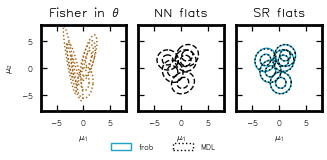

In [152]:
# plot a smattering of fishers


# COLOUR STUFF
fishercolour = "#1ea3c8"

myorange = '#a05a0a'

fishercolour = myorange
flatcolour = "#1ea3c8"

set_plot_fontsizes(base=8, ticks=7, legend=6, title=12)


randidx = np.random.choice(X_test.shape[0], size=(5), replace=False)

figwidth = 3.41
figheight = figwidth * 0.5
fig, axs = plt.subplots(1, 3, sharey=True, sharex=True, figsize=(figwidth, figheight))


ax = axs[0]

for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(Fs_test[r],ax=ax, mean=X_test[r], color=fishercolour, linestyle=':')

    else: 
        if i == len(randidx) - 1:
            labels = [None, None]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(Fs_test[r], mean=X_test[r], ax=ax, label=labels[1], linestyle=':', color=fishercolour)
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))







ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_title(r"Fisher in $\theta$")
ax.set_box_aspect(1)
ax = axs[1]



for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(nn_flats[r],ax=ax, mean=X_test[r], color='k', linestyle='--')

    else: 
        if i == len(randidx) - 1:
            labels = [None, None]
        else:
            labels = [None, None]
            
        plot_fisher_ellipse(nn_flats[r], mean=X_test[r], ax=ax, label=labels[0], linestyle='--', color='k')
        #plot_fisher_ellipse(score_flats[r], mean=X[r], ax=ax, label=labels[1], linestyle=':', color=cm(2))



mdl_evalues = []

# for i,r in enumerate(randidx):
#     if i == 0:
#         ax = plot_fisher_ellipse(mdl_flats[r],ax=ax, mean=X_test[r], color='k', linestyle=':')

#     else: 
#         if i == len(randidx) - 1:
#             # labels = ["MDL", "frob"]
#             labeles=[None,None]
#         else:
#             labels = [None, None]
        
#         plot_fisher_ellipse(mdl_flats[r], mean=X_test[r], ax=ax, label=labels[0], linestyle=':', color='k')

# ax.legend()

# ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_box_aspect(1)
ax.set_title("NN flats")



ax.set_box_aspect(1)




ax = axs[2]



for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(frob_flats[r],ax=ax, mean=X_test[r], color=flatcolour, linestyle='-')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(frob_flats[r], mean=X_test[r], ax=ax, label=labels[1], linestyle='-', color=flatcolour)




for i,r in enumerate(randidx):
    if i == 0:
        ax = plot_fisher_ellipse(mdl_flats[r],ax=ax, mean=X_test[r], color='k', linestyle=':')

    else: 
        if i == len(randidx) - 1:
            labels = ["MDL", "frob"]
        else:
            labels = [None, None]
        
        plot_fisher_ellipse(mdl_flats[r], mean=X_test[r], ax=ax, label=labels[0], linestyle=':', color='k')

# ax.set_ylabel(r"$\mu_2$")
ax.set_xlabel(r"$\mu_1$")
ax.set_xlim(-8, 8)
ax.set_ylim(-8, 8)
ax.set_box_aspect(1)
ax.set_title("SR flats")


fig.legend(
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=4,
    frameon=False,
    fontsize=7,
)
# fig.subplots_adjust(bottom=0.22)



plt.tight_layout()
plt.savefig("flats_comparison_true.pdf", dpi=400)

In [327]:
plt

<module 'matplotlib.pyplot' from '/usr/local/Caskroom/miniconda/base/envs/degen/lib/python3.12/site-packages/matplotlib/pyplot.py'>